# Machine Intelligence II
### PCA: batch preprocessing and online-PCA

**Group members: Nikita Bauer, Anastasija Markovska, Ibrahim Ulas Ayyilmaz, Rezwana Hussainzada**
---
**Exercise H2.1: Preprocessing**

*(a)* Load the dataset pca2.csv. Compute the Principal Components PC1 and PC2 and plot the data in the coordinate system PC2 vs. PC1. – What do you observe?


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

[3.15899214 1.20513042]
[[ 0.88773892 -0.46034728]
 [ 0.46034728  0.88773892]]


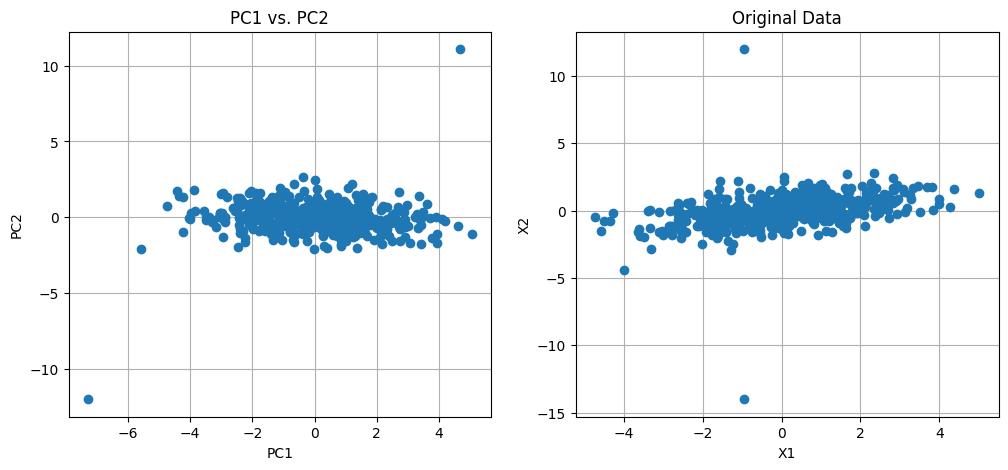

In [ ]:
path = "/content/drive/MyDrive/MI2/sheet02/pca2.csv"

data1 = pd.read_csv(path)

mean_data1 = np.mean(data1, axis=0)
centered_data1 = data1-mean_data1

cov_matrix1 = np.cov(centered_data1.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix1)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
print(eigenvalues)
eigenvectors = eigenvectors[:, idx]
print(eigenvectors)


projected_data1 = np.dot(centered_data1, eigenvectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.plot(projected_data1[:,0], projected_data1[:,1], 'o')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid()
ax1.set_title('PC1 vs. PC2')
ax2.plot(centered_data1["X1"], centered_data1["X2"], "o")
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.grid()
ax2.set_title('Original Data')

plt.show()


Two data points are outliers. They do not let us see the accurate shape of the rest of the data.

*(b)* Remove observations 17 and 157 (subtract 1 for zero-based indexing) and redo the above. What is the difference?

[3.05366443 0.64014267]
[[ 0.93549122 -0.35334993]
 [ 0.35334993  0.93549122]]


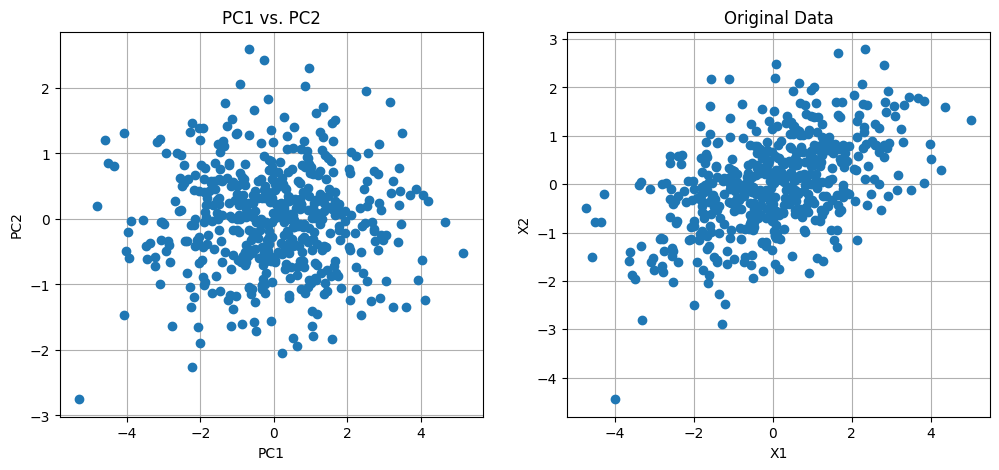

In [ ]:
data2 = data1.drop([16, 156])

mean_data2 = np.mean(data2, axis=0)
centered_data2 = data2-mean_data1

cov_matrix2 = np.cov(centered_data2.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix2)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
print(eigenvalues)
eigenvectors = eigenvectors[:, idx]
print(eigenvectors)


projected_data2 = np.dot(centered_data2, eigenvectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.plot(projected_data2[:,0], projected_data2[:,1], 'o')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid()
ax1.set_title('PC1 vs. PC2')
ax2.plot(centered_data2["X1"], centered_data2["X2"], "o")
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.grid()
ax2.set_title('Original Data')

plt.show()


Having removed the outliers, we observe that in the PC2 vs PC1 space, the data is more scattered and does not lie predominantly on PC1 and the positive correlation in the original data becomes more apparent. However, in the PCA plot (PC1 vs. PC2), this correlation disappears. This is because PCA transforms the data into a new coordinate system where the principal components are orthogonal (uncorrelated).

**Exercise H2.2: Sphering/Whitening**


*(a)* Load the dataset pca4.csv and visually inspect for outliers in the individual variables. Come up with a simple heuristic to remove the outliers from the data and proceed with using the “cleaned” data in all the next steps.


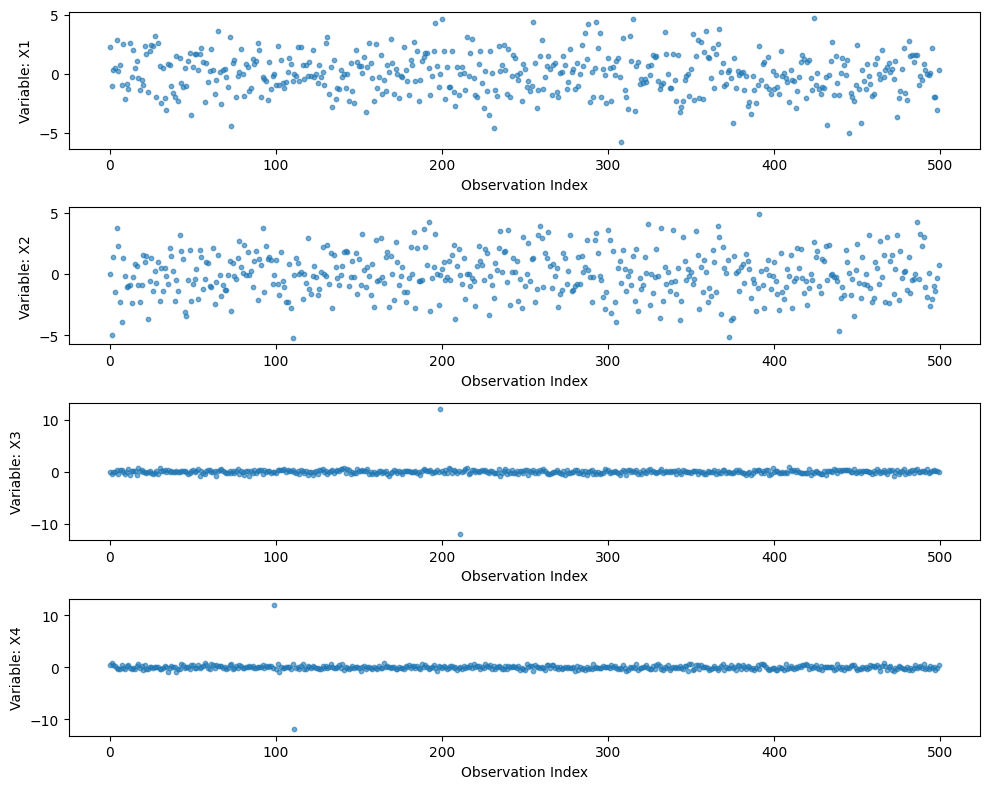

For var 1, samples with indices [] are removed
For var 2, samples with indices [] are removed
For var 3, samples with indices [199, 211] are removed
For var 4, samples with indices [99, 111] are removed
Total number of outliers removed: 4
The shape of the cleaned data is: (496, 4)


In [ ]:
path ="/content/drive/MyDrive/MI2/sheet02/pca4.csv"

# A
pca4_dataset = pd.read_csv(path)
pca4_centered = pca4_dataset - pca4_dataset.mean()

# plot each dimension(Variable) separately as a scatter plot, so I will observe for outliers
plt.figure(figsize=(10, 8))
for i, col in enumerate(pca4_centered.columns):
    plt.subplot(4, 1, i + 1)
    plt.scatter(range(len(pca4_centered)), pca4_centered[col].values, alpha=0.6, s=10)
    plt.ylabel(f'Variable: {col}')
    plt.xlabel('Observation Index')
plt.tight_layout()
plt.show()

# Heuristic to remove outliers to get "cleaned data"
stds = pca4_centered.std()
all_outlier_indices = set()

for i, col in enumerate(pca4_centered.columns):
    # Data is centered (mean=0), so outliers are points where |x| >= 5*std
    variable_outliers = pca4_centered.index[np.abs(pca4_centered[col]) >= 5 * stds[col]].tolist()
    print(f"For var {i+1}, samples with indices {variable_outliers} are removed")
    all_outlier_indices.update(variable_outliers)

# Define cleaned_data by removing all identified outliers
cleaned_data = pca4_centered.drop(index=list(all_outlier_indices))

print(f"Total number of outliers removed: {len(all_outlier_indices)}")
print(f"The shape of the cleaned data is: {cleaned_data.shape}")


(b) Perform PCA on a reasonable1 subset of this data. Use a scree plot to determine how many PCs represent the data well.

(62, 4)
[3.71894991 1.79458107 0.1156625  0.07722217]
[[-0.53047343 -0.84614588  0.05126069 -0.00272713]
 [-0.84697302  0.52693794 -0.06792701 -0.01894817]
 [ 0.00816211 -0.04890964 -0.68416022  0.72764416]
 [-0.03417645  0.06309837  0.7243501   0.68568762]]
(124, 4)
[3.80594981 1.92411636 0.10234477 0.09339453]
[[ 5.80074376e-01  8.14312829e-01 -3.42515763e-03 -1.99148994e-02]
 [ 8.14104618e-01 -5.79644135e-01 -3.10163236e-02  1.68622399e-02]
 [ 5.81337321e-04  2.43347699e-02  1.01186545e-01  9.94569638e-01]
 [ 2.73322176e-02 -1.77514307e-02  9.94377966e-01 -1.00748685e-01]]
(248, 4)
[3.8332545  2.09938392 0.10198109 0.09615877]
[[-0.5929013  -0.80526477  0.0013181  -0.00386943]
 [-0.80514117  0.59288754  0.00423026 -0.01463463]
 [ 0.0097463  -0.00366196  0.9062573  -0.42259829]
 [-0.01098925  0.00442869  0.4227033   0.90619068]]


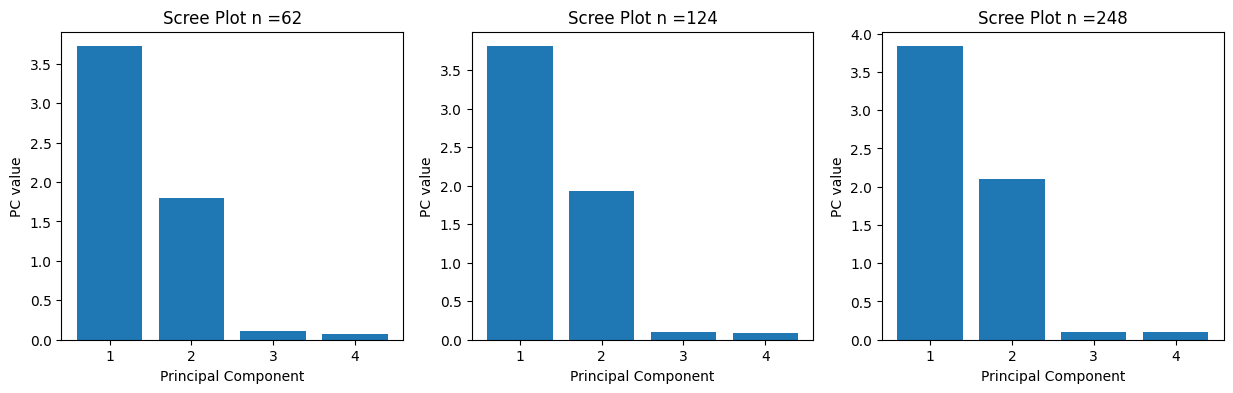

In [ ]:
# n = 62
data_subset = cleaned_data.sample(n=62, random_state=42)
print(data_subset.shape)

mean_data_subset = np.mean(data_subset, axis=0)
centered_data_subset = data_subset - mean_data_subset

cov_matrix = np.cov(centered_data_subset.T)
eigenvalues1, eigenvectors1 = np.linalg.eig(cov_matrix)

idx = eigenvalues1.argsort()[::-1]
eigenvalues1 = eigenvalues1[idx]
print(eigenvalues1)
eigenvectors1 = eigenvectors1[:, idx]
print(eigenvectors1)

# n = 124

data_subset = cleaned_data.sample(n=124, random_state=42)
print(data_subset.shape)

mean_data_subset = np.mean(data_subset, axis=0)
centered_data_subset = data_subset - mean_data_subset

cov_matrix = np.cov(centered_data_subset.T)
eigenvalues2, eigenvectors2 = np.linalg.eig(cov_matrix)

idx = eigenvalues2.argsort()[::-1]
eigenvalues2 = eigenvalues2[idx]
print(eigenvalues2)
eigenvectors2 = eigenvectors2[:, idx]
print(eigenvectors2)


# n = 248

data_subset = cleaned_data.sample(n=248, random_state=42)
print(data_subset.shape)

mean_data_subset = np.mean(data_subset, axis=0)
centered_data_subset = data_subset - mean_data_subset

cov_matrix = np.cov(centered_data_subset.T)
eigenvalues3, eigenvectors3 = np.linalg.eig(cov_matrix)

idx = eigenvalues3.argsort()[::-1]
eigenvalues3 = eigenvalues3[idx]
print(eigenvalues3)
eigenvectors3 = eigenvectors3[:, idx]
print(eigenvectors3)

#Scree plots
fig, ax = plt.subplots(1,3,figsize=(15,4))

ax[0].bar(range(1, 5), eigenvalues1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('PC value')
ax[0].set_title('Scree Plot n =62')

ax[1].bar(range(1, 5), eigenvalues2)
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('PC value')
ax[1].set_title('Scree Plot n =124')

ax[2].bar(range(1, 5), eigenvalues3)
ax[2].set_xlabel('Principal Component')
ax[2].set_ylabel('PC value')
ax[2].set_title('Scree Plot n =248')

plt.show()


*(c)* “Sphere”/“Whiten” the data, i.e. transform the data into 4 new uncorrelated-unit-variance variables. Each new variable should have mean 0 and a standard deviation equal to 1. This can be done e.g. using the transformation

$$\underline{V} = \underline{Λ}^{\frac{−1}{2}}\underline{M}^⊤\underline{X},$$

where, the new variables $v_i$ form the rows of $\underline{V}$, $\underline{M}$ is a matrix containing in its columns the normalized eigenvectors of the covariance matrix $\underline{C}$ of the centered data $\underline{X} ∈ R^{N×p}$ and $\underline{Λ}$ is a diagonal matrix containing the corresponding eigenvalues.

$$\underline{V} = \underline{M}^T \underline{X} \underline{M} \underline{Λ}^{\frac{1}{2}}$$


In [ ]:
# C)

# X is centered cleaned_100rows.
X_df = data_subset.copy()
# Recenter just in case
X_centered = X_df - X_df.mean()
# Transpose to shape (4, 100) as expected by the V formula
X = X_centered.T.values

# C is covarience matrix of X
# Note: np.cov with rowvar=True (default) computes covariance between rows, so C is 4x4
C = np.cov(X)

# M contains normalized eigenvalues of C (Note: assuming eigenvectors based on context M.T X)
eigenvalues_C, M = np.linalg.eigh(C)
idx_C = eigenvalues_C.argsort()[::-1]
eigenvalues_C = eigenvalues_C[idx_C]
M = M[:, idx_C]

# Lambda is a diagonal matrix containing eigenvalues
Lambda = np.diag(eigenvalues_C)

# compute V = Lambda^(-1/2) M.T X
Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eigenvalues_C))
V = Lambda_inv_sqrt @ M.T @ X

# We whiten/sphere the data using above equation where each new variable v_i (rows of V) has mean=0, std=1
# so that we get 4 uncorrelated variables

print(V.shape)



(4, 248)


*(d)* Generate 3 heatmap plots. Specifically a heatmap of:
1. the 4 × 4 covariance matrix $\underline{C}$,
2. the covariance matrix of the data projected onto all 4 PCs, i.e. $\underline{M}^⊤\underline{X}$, and
3. the covariance matrix of the transformed variables $v_i$.

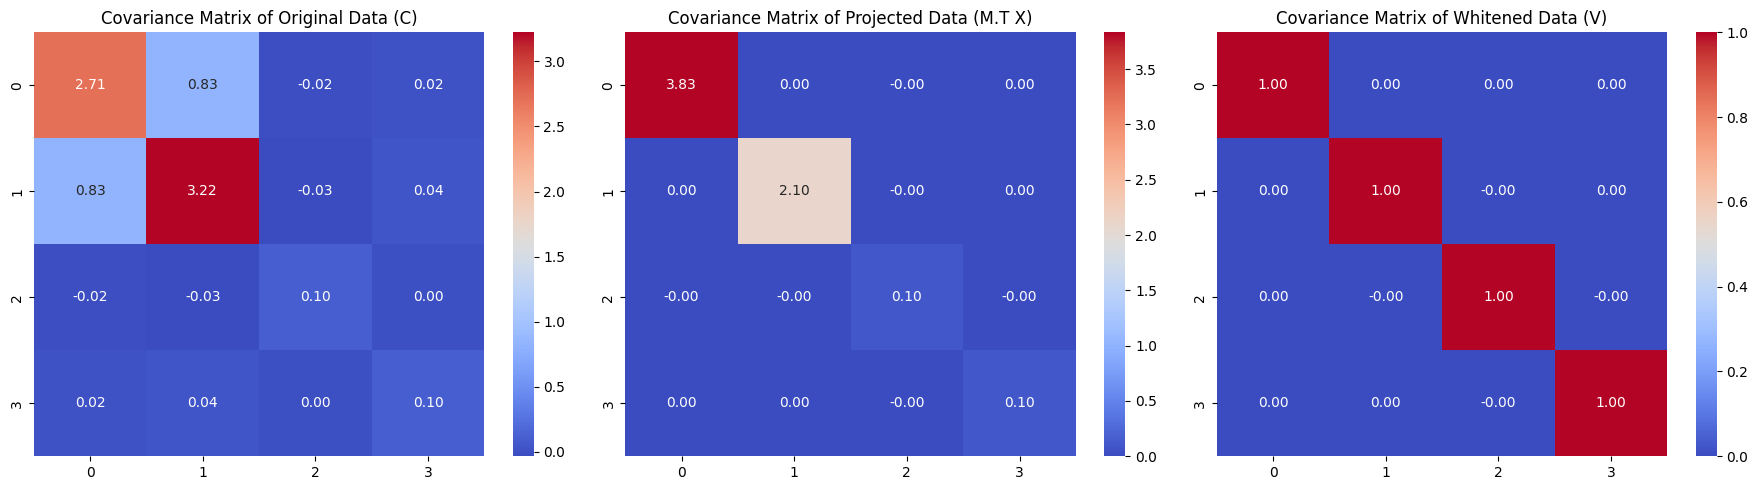

In [ ]:
# generate heatmaps in one figure (1 row, 3 columns)

import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Covariance matrix of original data (C)
sns.heatmap(
    C,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title('Covariance Matrix of Original Data (C)')


# 2. Covariance matrix of projected data (M.T X)
projected_X = M.T @ X
covar_projected_data = np.cov(projected_X)

sns.heatmap(
    covar_projected_data,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title('Covariance Matrix of Projected Data (M.T X)')


# 3. Covariance matrix of whitened data (V)
covar_V = np.cov(V)

sns.heatmap(
    covar_V,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[2]
)
axes[2].set_title('Covariance Matrix of Whitened Data (V)')


plt.tight_layout()
plt.show()

We observe that in the original data, the variables with highest variences are in the 0th and 1st dimensions. We also visualize that 0th and 1st variables are partially correlated with each other. And there is minimal correlation between any two pairs. Similarly variences of 2nd and 3rd variables are negligible.

When we project the data onto principle components and compute the covarience matrix, we observe that varience of the PC1 principle component is the highest, with the PC2 following. There is 0 correlation between variables, and variences of PC3 and PC4 are minimal.

For our whitened data, we observe a varience of 1 for each variable, with 0 correlation between pair-wise variables, as per definition.



**Exercise H2.3: Oja’s Rule: Derivation**

Consider a linear connectionist neuron whose output $y = y(t)$ at time t is an inner product of the $N$-dim input vector $\underline{x} = \underline{x}(t)$ with the N-dim weight vector w:
$$y = \underline{w}^⊤\underline{x}.$$
The Hebbian update rule for learning the weights can be written as

$$w_i(t + 1) = w_i(t) + εy(t)x_i(t),\ \ \ i = 1, 2, ...,N$$

where $ε$ is the learning rate and t is the iteration step. As was shown in the lecture, the Hebbian learning rule leads to a divergence of the length of the weight vector. Therefore, the following explicit normalization was introduced by Oja:

$$w_i(t + 1) =\frac{w_i(t) + εy(t)x_i(t)}{(∑_{j=1}^{N}[w_j(t) + εy(t)x_j(t)]^2)^{\frac{1}{2}}}$$

Task: Derive an approximation to this update rule for a small value of the learning rate parameter $ε$ by Taylor-expanding the right hand side of the equation with respect to $ε$ around $ε = 0$. Show that neglecting terms of second or higher order in ε gives Oja’s rule:
$$w_i(t + 1) = w_i(t) + εy(t) [x_i(t) − y(t)w_i(t)].$$


*Solution:*
for small $ε = 0$:

Assuming the weight vector is normalized at time $t$, i.e., $\left(\sum_{j=1}^{N} w_j^2(t)\right)^{1/2} = 1$:

$$
w_i(t+1)|_{ε=0}=\frac{w_i(t)}{(∑_{j=1}^{N} w_j(t))^\frac{1}{2}} = \frac{w_i(t)}{|w_i(t)|} = w_i(t)
$$
Applying the quotient rule $\left( \frac{u}{v} \right)' = \frac{u'v - uv'}{v^2}$ to the normalization equation:
\begin{equation*}
\frac{\partial w_i(t+1)}{\partial \epsilon} = \frac{yx_i \left( \sum_{j=1}^N (w_j + \epsilon y x_j)^2 \right)^{1/2} - \frac{1}{2} \left( \sum_{j=1}^N (w_j + \epsilon y x_j)^2 \right)^{-1/2} \left( 2 \sum_{j=1}^N (w_j + \epsilon y x_j)(y x_j) \right) (w_i + \epsilon y x_i)}{\sum_{j=1}^N (w_j + \epsilon y x_j)^2}
\end{equation*}

Substituting $\epsilon = 0$ into the derivative, and using the definition $y = \sum_{j=1}^{N} w_j x_j$:

\begin{equation*}
\frac{\partial w_i(t+1)}{\partial \epsilon} \bigg|_{\epsilon=0} = \frac{yx_i - \left( \sum_{j=1}^N w_j(t)x_j \right) y w_i(t)}{1} = y \left( x_i - y w_i(t) \right)
\end{equation*}

Using the first-order Taylor expansion, we obtain:
$$
w_i(t+1) = w_i(t) + \epsilon y(t) [x_i(t) - y(t)w_i(t)] + O(\epsilon^2)
$$




**Exercise H2.4: Oja’s Rule: Application**

The file data-onlinePCA.txt contains observations from an experiment run over an interval of time. The first datapoint was observed at $t_0 = 0$ and the last at $t_T = 10s$.

*(a)* Produce a scatter plot of the data and indicate the time index by the color of the datapoints.
You can break the full dataset into 10 blocks corresponding to 1 second length each and use 10 different colors, 1 color for each block.



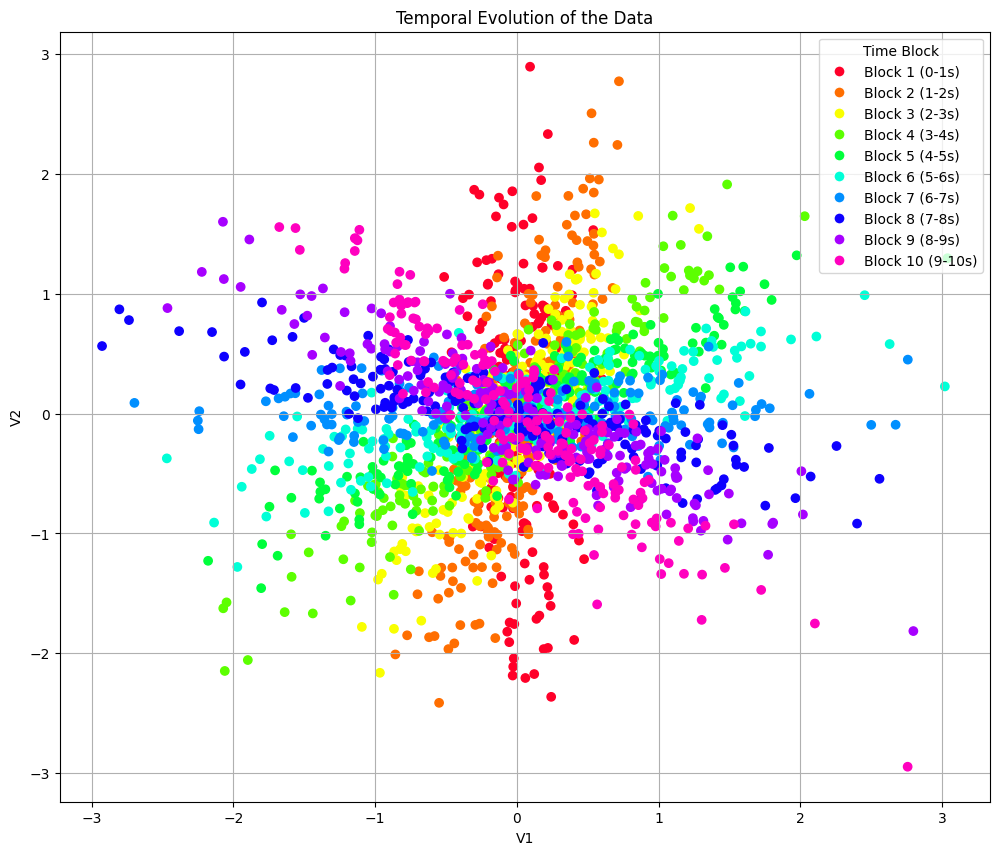

(2000, 2)


In [ ]:
import numpy as np
import pandas as pd
path = "/content/drive/MyDrive/MI2/sheet02/data-onlinePCA.txt"

data = np.loadtxt(path, skiprows=1, delimiter=",", usecols=range(1,3)) # 2000 observations, 2 features; each data point is 1/200 of a second

import matplotlib.cm as cm

colours = cm.gist_rainbow(np.linspace(0, 1, 10))
block_colours = np.repeat(colours, 200, axis=0)

fig, ax = plt.subplots(figsize=(12,10))
sc = ax.scatter(data[:,0], data[:,1], c=block_colours)

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[i],
                       markersize=8, label=f"Block {i+1} ({i}-{i+1}s)") for i in range(10)]
ax.legend(handles=handles, title="Time Block")

ax.set_xlabel("V1")
ax.set_ylabel("V2")
ax.grid(True)
ax.set_title("Temporal Evolution of the Data")
plt.show()
print(data.shape)


*(b)* Determine the principal components, using batch PCA, for each of the 10 blocks separately. Plot the direction of first PC for each block (e.g. as an arrow or the endpoint of it) together with the original data.

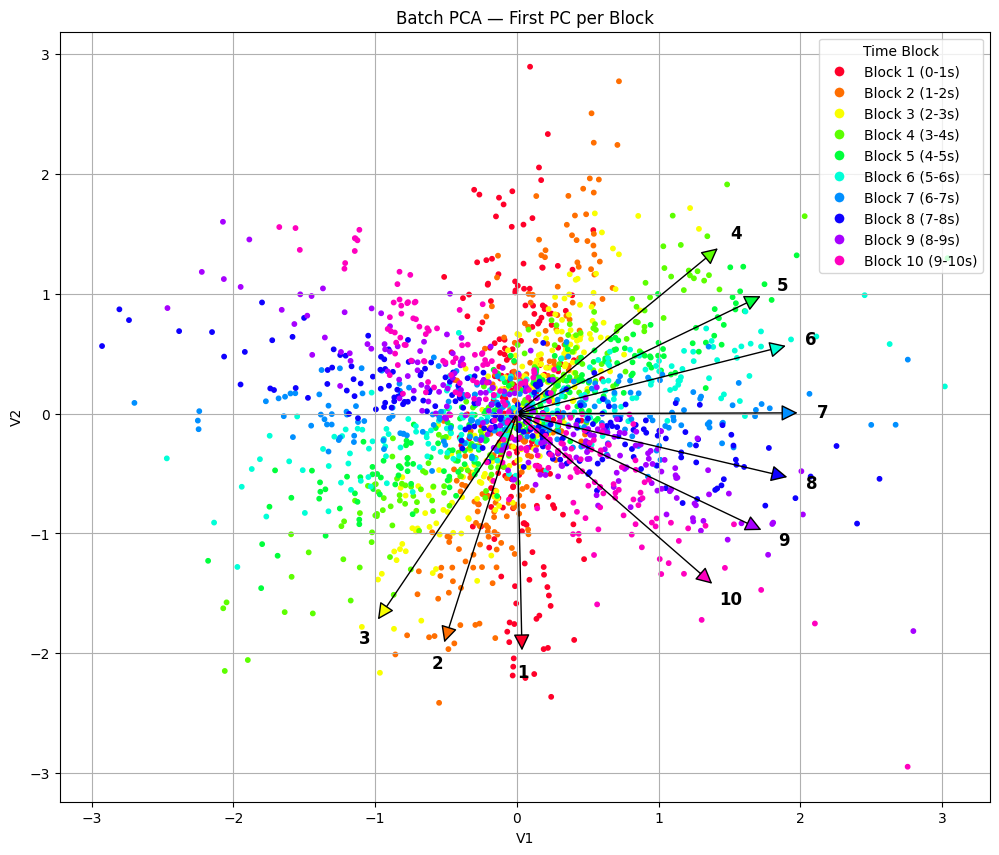

In [ ]:
ten_eigenvecs = []

for i in range(10):
    subset = data[i * 200 : (i+1) * 200]

    C = np.cov(subset, rowvar=False)
    eigenvals, eigenvecs = np.linalg.eig(C)

    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]

    ten_eigenvecs.append(eigenvecs[:, 0])

arr_length = 2.0
centre = np.array([0, 0])

fig, ax = plt.subplots(figsize=(12, 10))

# scatter plot
ax.scatter(data[:, 0], data[:, 1], c=block_colours, s=10, zorder=1)

# draw arrows + numbers
for i, pc in enumerate(ten_eigenvecs):

    tip = centre + arr_length * pc

    # arrow
    ax.annotate(
        "",
        xy=tip,
        xytext=centre,
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            lw=1,
            mutation_scale=25,
            fc=colours[i],
        ),
        zorder=3
    )

    # add number near arrow tip
    ax.text(
        tip[0] * 1.08,   # little offset
        tip[1] * 1.08,
        str(i + 1),
        fontsize=12,
        fontweight='bold',
        color='black',
        ha='center',
        va='center',
        zorder=4
    )

# legend
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colours[i],
        markersize=8,
        label=f"Block {i+1} ({i}-{i+1}s)"
    )
    for i in range(10)
]

ax.legend(handles=handles, title="Time Block")

ax.set_xlabel("V1")
ax.set_ylabel("V2")
ax.grid(True)
ax.set_title("Batch PCA — First PC per Block")

plt.show()

*(c)* Implement Oja’s rule and apply it with a learning rate parameter $ε ∈ \{0.002, 0.04, 0.45\}$ to the dataset. In each iteration, take the next data point and apply the learning step. Plot the weights at each timestep (as points whose x vs. y coordinates are given by the weight for x and y) in the same plot as the original data. Use the colors from (a) to indicate the time index for each plotted weight.

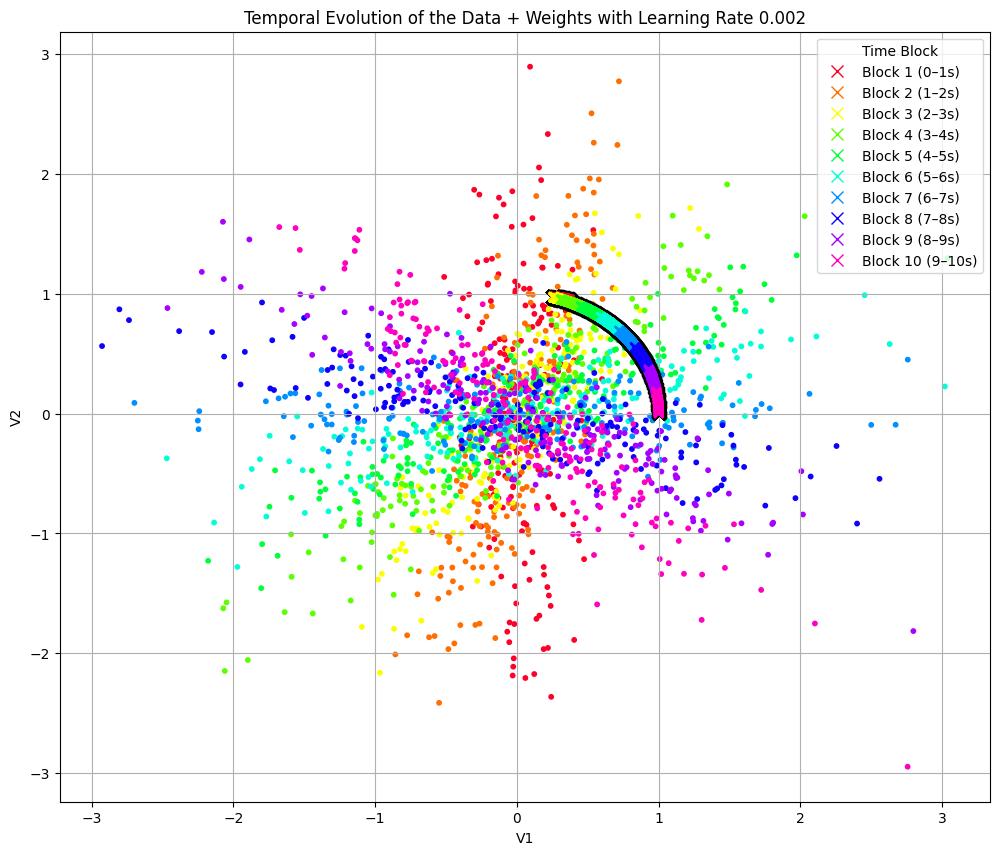

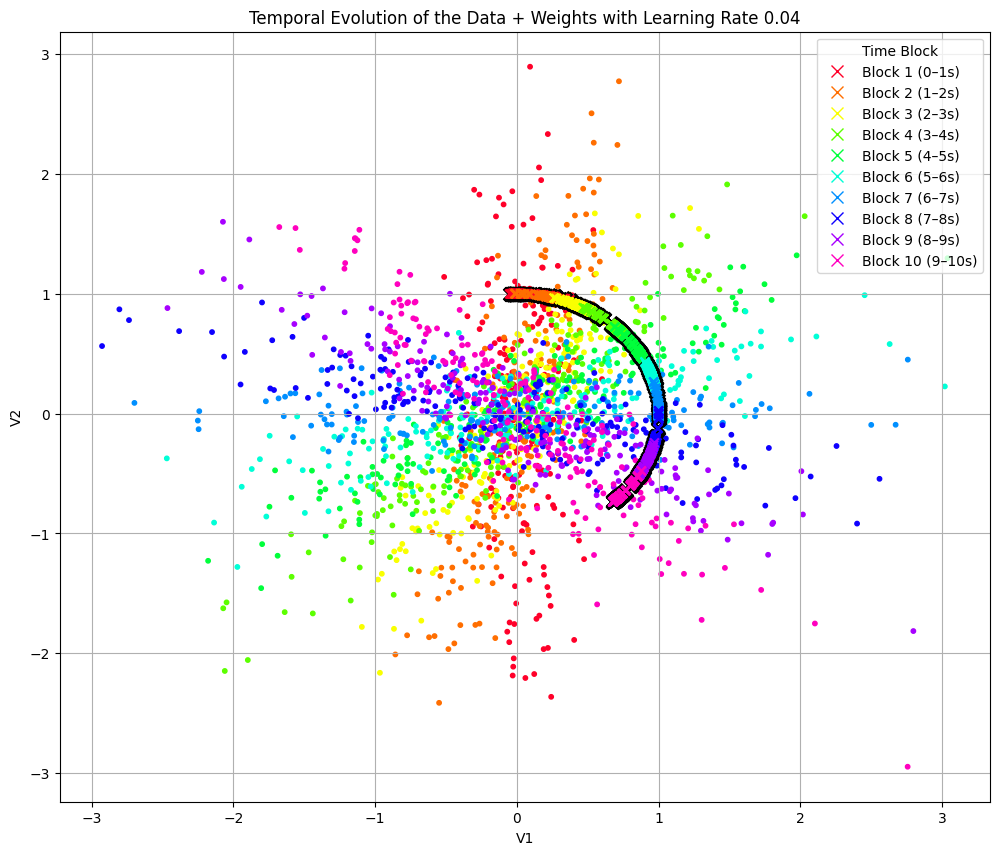

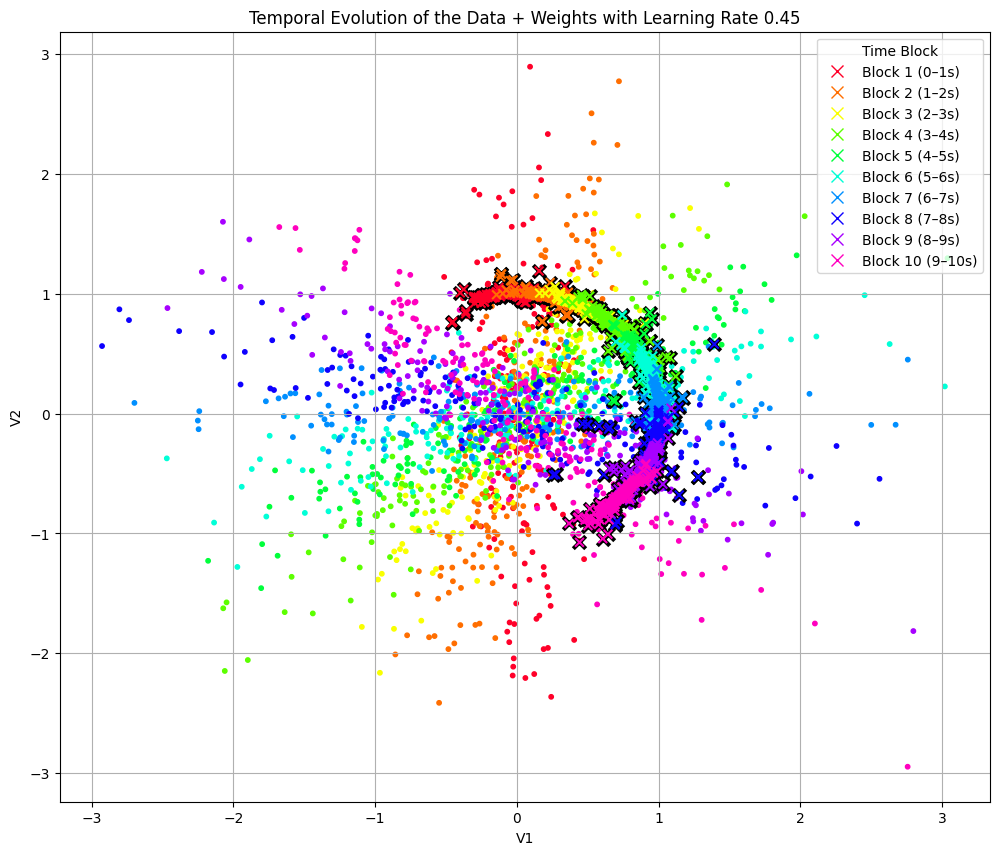

In [ ]:
# wi(t + 1) = wi(t) + εy(t) [xi(t) − y(t)wi(t)] .
lr = [0.002, 0.04, 0.45]

colours = cm.gist_rainbow(np.linspace(0, 1, 10))
block_colours = np.repeat(colours, 200, axis=0)

np.random.seed(42)
w_0 = np.random.rand(2)

for l in lr:
    w_t = w_0.copy()
    weights = []

    for i in range(data.shape[0]):
        y_t = w_t @ data[i]
        w_t += l * y_t * (data[i] - y_t * w_t)
        weights.append(w_t.copy())  # <-- note: .copy() is important here!

    weights = np.array(weights)

    fig, ax = plt.subplots(figsize=(12,10))
    ax.scatter(data[:,0], data[:,1], c=block_colours, s=10, zorder=1)

    # black outline layer
    ax.scatter(weights[:,0], weights[:,1], c="black", marker="x",
               s=80, linewidths=3, zorder=2)
    # coloured layer on top
    ax.scatter(weights[:,0], weights[:,1], c=block_colours, marker="x",
               s=40, linewidths=1.5, zorder=3)

    handles = [plt.Line2D([0],[0], marker='x', color='w', markerfacecolor=colours[i],
                           markeredgecolor=colours[i], markersize=8,
                           label=f"Block {i+1} ({i}–{i+1}s)") for i in range(10)]
    ax.legend(handles=handles, title="Time Block")
    ax.set_xlabel("V1")
    ax.set_ylabel("V2")
    ax.grid(True)
    ax.set_title(f"Temporal Evolution of the Data + Weights with Learning Rate {l}")
    plt.show()

We observe that if $y$ is large (when a datapoint $x$ is further from the origin), the weight update becomes significant in the direction of that datapoint. In this case, Oja’s normalization term becomes even larger, resulting in slight deviations from the unit circle path as the weight vector is pulled back toward the origin. Conversely, if $y$ is small (when a datapoint $x$ is closer to the origin), the weight update toward the outskirts is minimal, and Oja’s normalization is even smaller. This dynamic effectively constrains the weight vector to follow a circular pattern over time with a radius of approximately 1.

For $\epsilon = 0.45$, because the updates are aggressive in all directions, the weight vectors deviate sharply outwards and inwards with each single update, leading to instability. For $\epsilon = 0.04$, the updates are large enough to allow the weight to converge to the actual path, yet small enough to maintain the vector stably on the unit circle. Finally, for $\epsilon = 0.001$, the updates are too small, which does not provide enough momentum for the weights to converge within the given timeframe.